In [9]:
import pandas as pd
import re

# Load data asli (belum diproses)
df = pd.read_csv('/content/Data_Sentimen_MBG_Clean.csv')

print("DATA ASLI:")
print(f"Jumlah data: {len(df)}")
print(f"Kolom: {df.columns.tolist()}")

# Lihat 5 data pertama
print("\n5 Data Pertama:")
print(df.head())

# Buat fungsi auto labeling seperti di notebook Anda
def auto_label(text):
    text = str(text).lower()

    # Kata positif
    positif = ['bagus','keren','mantap','baik','hebat','setuju','dukung','senang','suka','terima kasih','support','good']
    # Kata negatif
    negatif = ['jelek','buruk','korupsi','maling','rusak','parah','gagal','bodoh','sengsara','benci','tidak setuju']

    if any(word in text for word in positif):
        return 'Positif'
    elif any(word in text for word in negatif):
        return 'Negatif'
    else:
        return 'Negatif'  # default negatif

# Terapkan labeling
df['sentimen'] = df['komentar'].apply(auto_label)

print("\nDISTRIBUSI SENTIMEN HASIL AUTO LABEL:")
print(df['sentimen'].value_counts())

# Hitung jumlah Positif
positif_count = len(df[df['sentimen'] == 'Positif'])
negatif_count = len(df[df['sentimen'] == 'Negatif'])

print(f"\nJumlah Positif: {positif_count}")
print(f"Jumlah Negatif: {negatif_count}")

# Filter kolom yang diperlukan
df_clean = df[['author', 'published_at', 'like_count', 'komentar', 'sentimen']].copy()
df_clean = df_clean.rename(columns={
    'published_at': 'published_at',
    'komentar': 'komentar'
})

# Simpan data bersih dengan label
df_clean.to_csv('/content/Data_Sentimen_MBG_Labeled.csv', index=False)
print("\nData disimpan sebagai: Data_Sentimen_MBG_Labeled.csv")
print(f"Total data: {len(df_clean)}")
print(f"Positif: {positif_count}, Negatif: {negatif_count}")

DATA ASLI:
Jumlah data: 6419
Kolom: ['author', 'published_at', 'like_count', 'komentar', 'sentimen']

5 Data Pertama:
                author          published_at  like_count  \
0            @Ipank049  2026-03-15T19:00:49Z           0   
1           @Tmsaja873  2026-03-15T11:15:42Z           0   
2  @fakhrieofisial4819  2026-03-15T07:36:34Z           0   
3    @sudaryadidar1358  2026-03-14T08:23:35Z           0   
4         @KokGiniAmat  2026-03-14T06:33:38Z           0   

                                            komentar sentimen  
0  Penguasa dan Pelaksana Program MBG menjadi Pen...  Negatif  
1            anaknya makan 1x bapaknya penganguran..  Negatif  
2  Rusak lah negara kalau Nepotisme, korupsi sema...  Negatif  
3  Programpresiden jokowi. Berobat gratid banyak ...  Negatif  
4                               Maling Berkedok Gizi  Negatif  

DISTRIBUSI SENTIMEN HASIL AUTO LABEL:
sentimen
Negatif    5490
Positif     929
Name: count, dtype: int64

Jumlah Positif: 929
Jumlah Neg

Library berhasil diimport
DATA YANG DIGUNAKAN:
Jumlah data: 6419
sentimen
Negatif    5490
Positif     929
Name: count, dtype: int64
Data Positif: 929 sampel
Data Negatif: 5490 sampel
Data setelah cleaning: 6369
Label encoding: {'Negatif': np.int64(0), 'Positif': np.int64(1)}

Data training: 5095
Data testing: 1274
Distribusi training: Positif=743 Negatif=4352
Distribusi testing: Positif=186 Negatif=1088

TF-IDF VECTORIZER
Shape TF-IDF training: (5095, 3000)
Shape TF-IDF testing: (1274, 3000)

MODEL MACHINE LEARNING

Training Logistic Regression...
Accuracy: 90.66%
F1-Score: 0.8870

Training Naive Bayes...
Accuracy: 87.60%
F1-Score: 0.8344

Training SVM...
Accuracy: 94.35%
F1-Score: 0.9376

HASIL PERBANDINGAN MODEL
              Model  Accuracy  F1-Score
                SVM  0.943485  0.937608
Logistic Regression  0.906593  0.887048
        Naive Bayes  0.875981  0.834396

Model terbaik: SVM dengan akurasi 94.35%

EVALUASI DETAIL - SVM

Classification Report:
              precision    

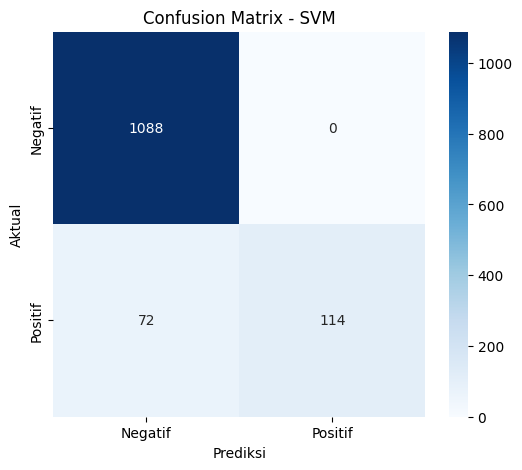


EVALUASI SEMUA MODEL

Logistic Regression:
              precision    recall  f1-score   support

     Negatif       0.90      1.00      0.95      1088
     Positif       1.00      0.36      0.53       186

    accuracy                           0.91      1274
   macro avg       0.95      0.68      0.74      1274
weighted avg       0.92      0.91      0.89      1274



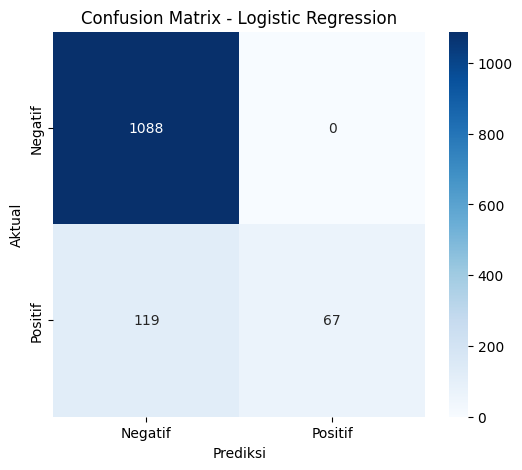


Naive Bayes:
              precision    recall  f1-score   support

     Negatif       0.87      1.00      0.93      1088
     Positif       1.00      0.15      0.26       186

    accuracy                           0.88      1274
   macro avg       0.94      0.58      0.60      1274
weighted avg       0.89      0.88      0.83      1274



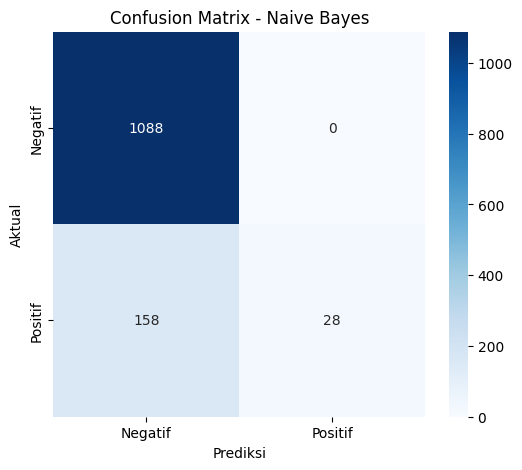


SVM:
              precision    recall  f1-score   support

     Negatif       0.94      1.00      0.97      1088
     Positif       1.00      0.61      0.76       186

    accuracy                           0.94      1274
   macro avg       0.97      0.81      0.86      1274
weighted avg       0.95      0.94      0.94      1274



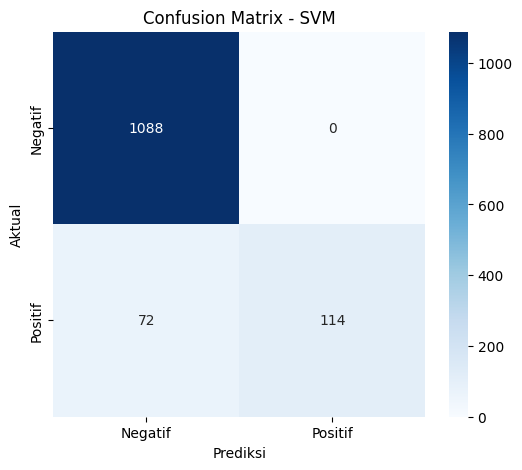


VISUALISASI PERBANDINGAN


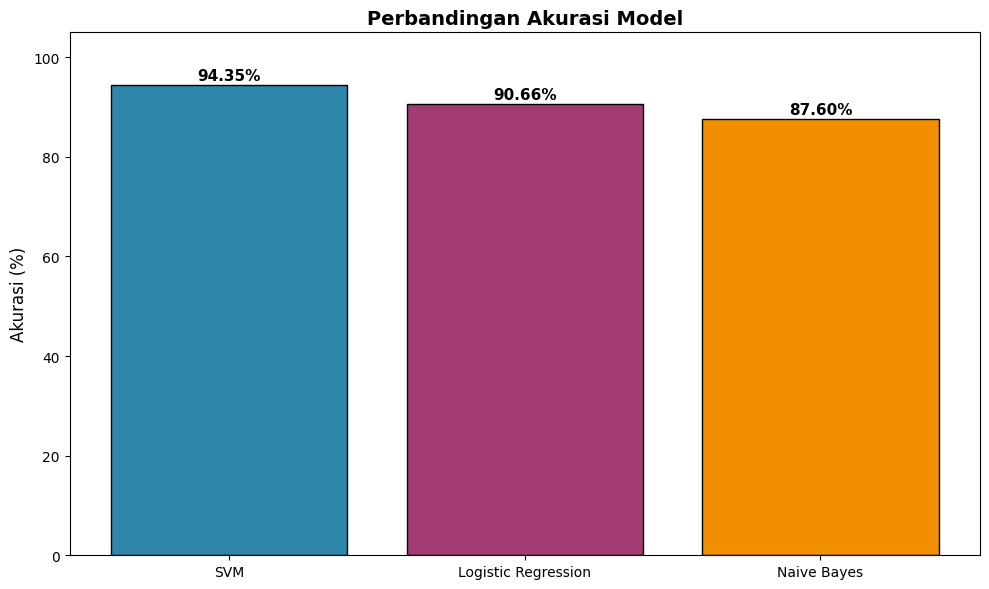


Model telah disimpan:
- best_ml_model.pkl
- tfidf_vectorizer.pkl
- label_encoder.pkl

Model terbaik yang disimpan: SVM


In [16]:
# ============================================
# IMPORT LIBRARY
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

print("Library berhasil diimport")

# ============================================
# LOAD DATA YANG SUDAH DILABEL
# ============================================
df = pd.read_csv('/content/Data_Sentimen_MBG_Labeled.csv')

print("DATA YANG DIGUNAKAN:")
print(f"Jumlah data: {len(df)}")
print(df['sentimen'].value_counts())

# Cek jumlah Positif
positif_count = len(df[df['sentimen'] == 'Positif'])
negatif_count = len(df[df['sentimen'] == 'Negatif'])

if positif_count == 0:
    print("ERROR: Tidak ada data Positif!")
else:
    print(f"Data Positif: {positif_count} sampel")
    print(f"Data Negatif: {negatif_count} sampel")

# ============================================
# PREPROCESSING TEKS
# ============================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['komentar_bersih'] = df['komentar'].apply(clean_text)

# Hapus data kosong
df = df[df['komentar_bersih'].str.len() > 0].reset_index(drop=True)
print(f"Data setelah cleaning: {len(df)}")

# ============================================
# ENCODE LABEL
# ============================================
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentimen'])
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ============================================
# SPLIT DATA
# ============================================
X = df['komentar_bersih'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData training: {len(X_train)}")
print(f"Data testing: {len(X_test)}")
print(f"Distribusi training: Positif={sum(y_train==1)} Negatif={sum(y_train==0)}")
print(f"Distribusi testing: Positif={sum(y_test==1)} Negatif={sum(y_test==0)}")

# ============================================
# TF-IDF VECTORIZER
# ============================================
print("\n" + "="*60)
print("TF-IDF VECTORIZER")
print("="*60)

tfidf = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.95)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape TF-IDF training: {X_train_tfidf.shape}")
print(f"Shape TF-IDF testing: {X_test_tfidf.shape}")

# ============================================
# MODEL MACHINE LEARNING
# ============================================
print("\n" + "="*60)
print("MODEL MACHINE LEARNING")
print("="*60)

# Daftar model (hanya 3)
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42)
}

results = []
best_model = None
best_accuracy = 0

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({'Model': name, 'Accuracy': accuracy, 'F1-Score': f1})
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"F1-Score: {f1:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_name = name

# Hasil perbandingan
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n" + "="*50)
print("HASIL PERBANDINGAN MODEL")
print("="*50)
print(results_df.to_string(index=False))

print(f"\nModel terbaik: {best_name} dengan akurasi {best_accuracy*100:.2f}%")

# ============================================
# EVALUASI DETAIL MODEL TERBAIK
# ============================================
print("\n" + "="*60)
print(f"EVALUASI DETAIL - {best_name}")
print("="*60)

y_pred_best = best_model.predict(X_test_tfidf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# ============================================
# EVALUASI SEMUA MODEL
# ============================================
print("\n" + "="*60)
print("EVALUASI SEMUA MODEL")
print("="*60)

for name, model in models.items():
    print(f"\n{name}:")
    y_pred = model.predict(X_test_tfidf)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix untuk setiap model
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

# ============================================
# VISUALISASI PERBANDINGAN AKURASI
# ============================================
print("\n" + "="*60)
print("VISUALISASI PERBANDINGAN")
print("="*60)

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy']*100,
               color=['#2E86AB', '#A23B72', '#F18F01'], edgecolor='black')
plt.ylabel('Akurasi (%)', fontsize=12)
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
plt.ylim(0, 105)

for bar, acc in zip(bars, results_df['Accuracy']*100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# SAVE MODEL TERBAIK
# ============================================
import joblib

joblib.dump(best_model, '/content/best_ml_model.pkl')
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')
joblib.dump(le, '/content/label_encoder.pkl')

print("\nModel telah disimpan:")
print("- best_ml_model.pkl")
print("- tfidf_vectorizer.pkl")
print("- label_encoder.pkl")
print(f"\nModel terbaik yang disimpan: {best_name}")

In [19]:
# ============================================
# TESTING PREDIKSI DENGAN MODEL TERBAIK
# ============================================
import joblib
import re

# Load model
best_model = joblib.load('/content/best_ml_model.pkl')
tfidf = joblib.load('/content/tfidf_vectorizer.pkl')
le = joblib.load('/content/label_encoder.pkl')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def predict_sentimen(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    return le.inverse_transform([pred])[0]

# Test
test_texts = [
    "Program MBG sangat bagus, anak-anak jadi semangat belajar",
    "Ini hanya program korupsi, rakyat semakin sengsara",

]

print("\nHASIL PREDIKSI:")
print("="*40)
for text in test_texts:
    hasil = predict_sentimen(text)
    print(f"\nTeks: {text}")
    print(f"Sentimen: {hasil}")


HASIL PREDIKSI:

Teks: Program MBG sangat bagus, anak-anak jadi semangat belajar
Sentimen: Positif

Teks: Ini hanya program korupsi, rakyat semakin sengsara
Sentimen: Negatif
